# Health and Poverty Across US Counties

*Team project for SI 618: Data Analysis and Manipulation, with Vaishnavi Venkataraghavan and James Gair. Full notebooks: [GitHub](https://github.com/shreya-gupta-um/us-county-health-poverty-analysis).*

We combined CDC PLACES county-level health data with Census ACS poverty and income data to ask a simple question: how much does poverty track with health outcomes across U.S. counties, and does that relationship hold up statistically once you look past Michigan to the rest of the country?

## Setting the Baseline: Michigan

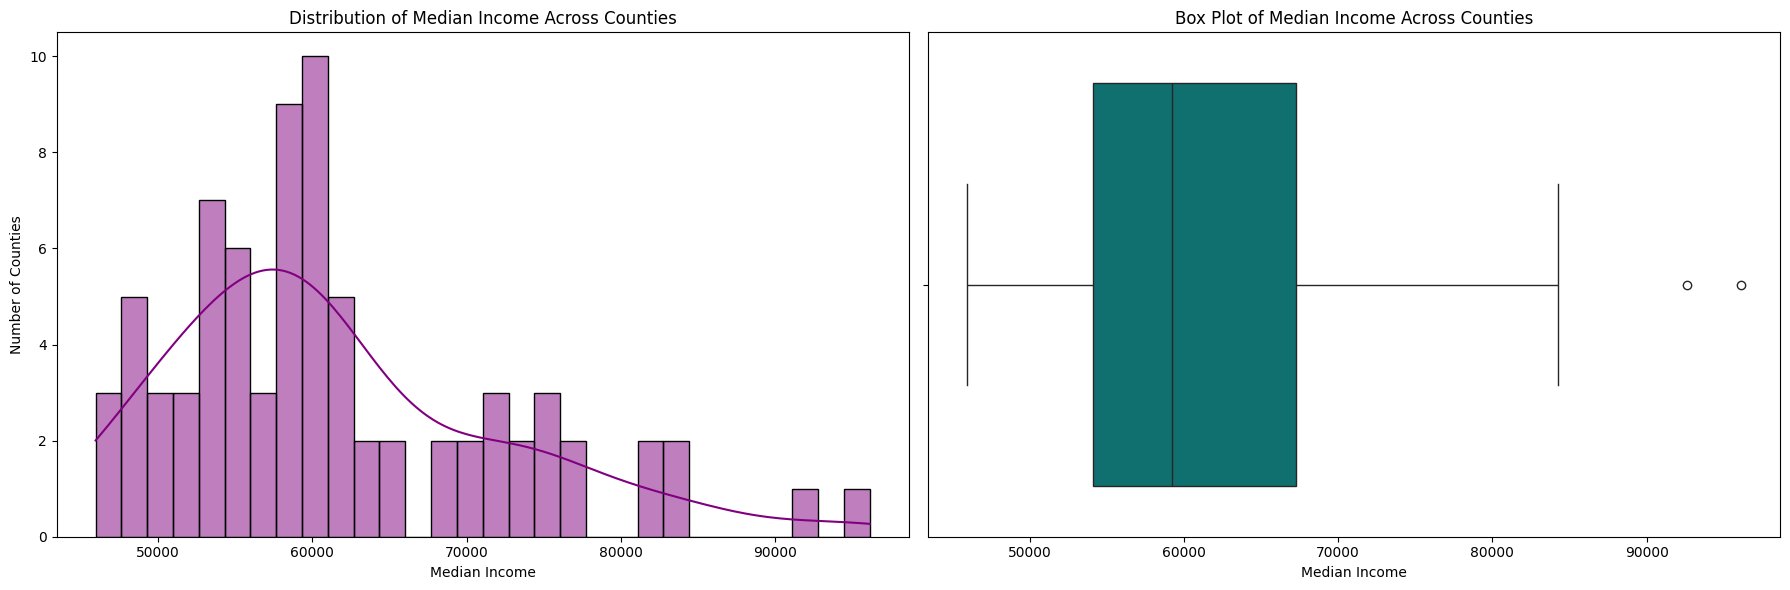

In [31]:
# Set figure size for both plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Histogram: Distribution of Median Income
sns.histplot(unique_mi_df['Median income'], bins=30, kde=True, ax=axes[0], color='purple')
axes[0].set_title("Distribution of Median Income Across Counties")
axes[0].set_xlabel("Median Income")
axes[0].set_ylabel("Number of Counties")

# Box Plot: Spread of Median Income
sns.boxplot(x=unique_mi_df['Median income'], ax=axes[1], color='teal')
axes[1].set_title("Box Plot of Median Income Across Counties")
axes[1].set_xlabel("Median Income")

# Adjust layout and show plots
plt.tight_layout()
plt.show()

We can infer the following:

The histogram reveals that most counties in Michigan have a median income ranging from **$55k to $70k**. However, there are some extreme tails and outliers--a few counties show median incomes **below $50k** and others above **$90k**. This might suggest that while the majority of counties fall within the middle-income range, there are certain areas with significantly lower or higher incomes which could contribute to regional income disparities.

The box plot further confirms these trends by highlighting the spread of values.

## Does Poverty Predict Health Outcomes Nationwide?

Moving beyond Michigan, we merged the full CDC PLACES and Census ACS datasets, over 120,000 county-level health records, and tested whether poverty rate meaningfully predicts each health outcome.

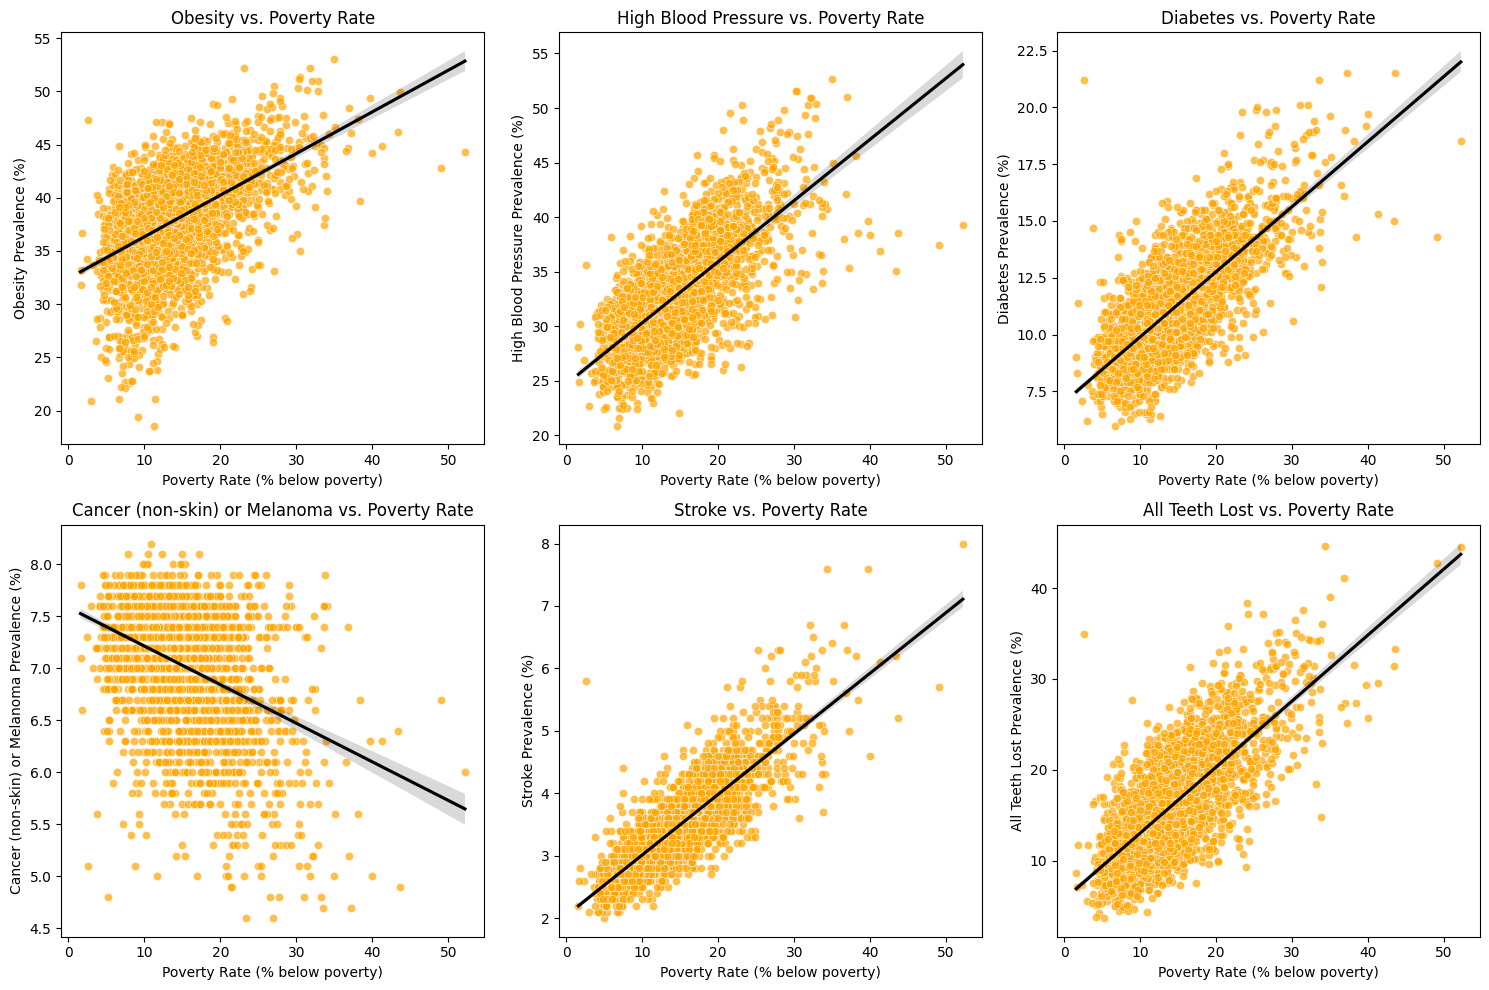

In [20]:
# Define a list of commonly known health outcomes for analysis
key_health_outcomes = ['Obesity', 'High Blood Pressure', 'Diabetes', 'Cancer (non-skin) or Melanoma', 'Stroke', 'All Teeth Lost']

plt.figure(figsize=(15, 10))

for i, outcome in enumerate(key_health_outcomes):
    plt.subplot(2, 3, i+1)

    # Filter data for the selected outcome
    outcome_data = df[df["Health_Measure"] == outcome]
    
    # Create scatter plot with a regression line
    sns.scatterplot(
        x=outcome_data["BP_ Total%"], 
        y=outcome_data["Pop_Percent"],  
        color="orange", 
        alpha=0.7,
        legend=False
    )

    sns.regplot(
        x=outcome_data["BP_ Total%"], 
        y=outcome_data["Pop_Percent"], 
        scatter=False, 
        color='black'
    )
    
    plt.xlabel("Poverty Rate (% below poverty)")
    plt.ylabel(f"{outcome} Prevalence (%)")
    plt.title(f"{outcome} vs. Poverty Rate")
    
plt.tight_layout()
plt.show()

#### This scatterplot with a regression line visualizes the relationship between **poverty rates** and **health outcomes**, highlighting how prevalence changes as poverty levels rise.

1. **Clear Positive Trends**
- Four conditions—**Obesity**, **High Blood Pressure**, **Diabetes**, and **Stroke**—exhibit upward trends, meaning they become more prevalent as poverty rates increase.
- This suggests a strong correlation between higher poverty levels and the worsening of these chronic conditions.

2. **Strongest Association: Stroke**
- Among these conditions, Stroke has the steepest regression slope, suggesting it is most sensitive to poverty rate changes.

3. **Cancer (Non-Skin or Melanoma): The Exception**
- Unlike other conditions, **Cancer** shows a weaker or slightly negative slope, meaning its prevalence is less affected by poverty levels.

4. **Distribution & Spread of Data Points**
- The scatter cloud varies for different conditions:
  - Obesity values are clustered between 25% and 45%, indicating that obesity is widespread but does not fluctuate dramatically between counties.
  - Stroke prevalence ranges from 2% to significantly higher values, suggesting it may be more influenced by multiple factors.

5. **Regression Line & Outliers**
- The black regression line visualizes the overall trend, reinforcing the relationship between poverty and health outcomes.
- However, outliers exist at both extremes:
  - Low-poverty counties with unexpectedly high health risks.
  - High-poverty counties with better-than-expected health outcomes.

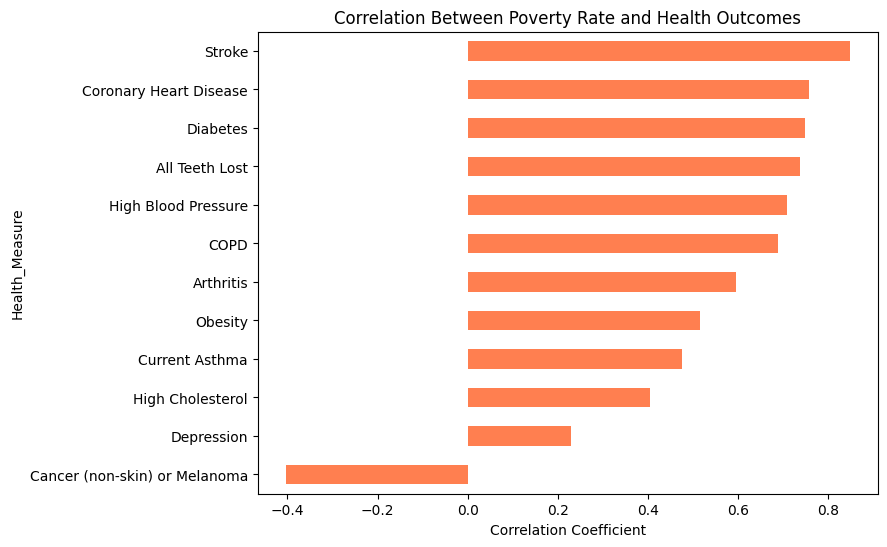

In [22]:
# Use the pivot_disease function to create a pivot table for Health Outcomes
pivot_health = pivot_disease(df)

# Compute correlation coefficients between poverty rate and each health outcome, making sure to select only numeric columns.
numeric_pivot = pivot_health.select_dtypes(include=['number'])

# Now compute the correlation matrix on numeric data only
poverty_correlations = numeric_pivot.corr()['BP_ Total%'].drop('BP_ Total%')

# Plot the correlations as a horizontal bar chart
plt.figure(figsize=(8, 6))
poverty_correlations.sort_values().plot(kind='barh', color='coral')
plt.xlabel("Correlation Coefficient")
plt.title("Correlation Between Poverty Rate and Health Outcomes")
plt.show()

#### Each bar represents the **correlation coefficient** between **BP_Total%** (poverty rate) and a particular health outcome.

1. **Positive vs. Negative Correlations**

- Bars extending to the right of zero indicate positive correlations, meaning the condition becomes more prevalent as poverty increases (e.g., Stroke, Coronary Heart Disease, Diabetes).
- Bars extending to the left indicate a negative correlation, meaning the condition is less prevalent in higher-poverty areas (Cancer).

2. **Relative Strength of Correlations**

- Stroke has the strongest positive correlation, reinforcing the earlier observation that stroke prevalence is highly sensitive to poverty levels.
- Cancer is the only condition with a negative correlation, suggesting that higher poverty may be linked to lower reported prevalence—possibly due to differences in screening rates, diagnostic access, or underreporting in poorer counties.


3. **Moderate to Strong Correlations**

- Most conditions—Arthritis, Obesity, High Cholesterol, High Blood Pressure, and Diabetes—fall in the moderate to strong positive correlation range (0.3–0.7), suggesting a consistent association between poverty and these chronic diseases.
- Depression (~0.2 correlation) shows a weaker relationship with poverty, indicating that mental health outcomes are influenced by additional socioeconomic or cultural factors beyond income alone.

## Risk Behaviors and Racial Disparities

We also looked at health risk behaviors (smoking, inactivity, and similar) and at how the poverty-health relationship differs across racial groups.

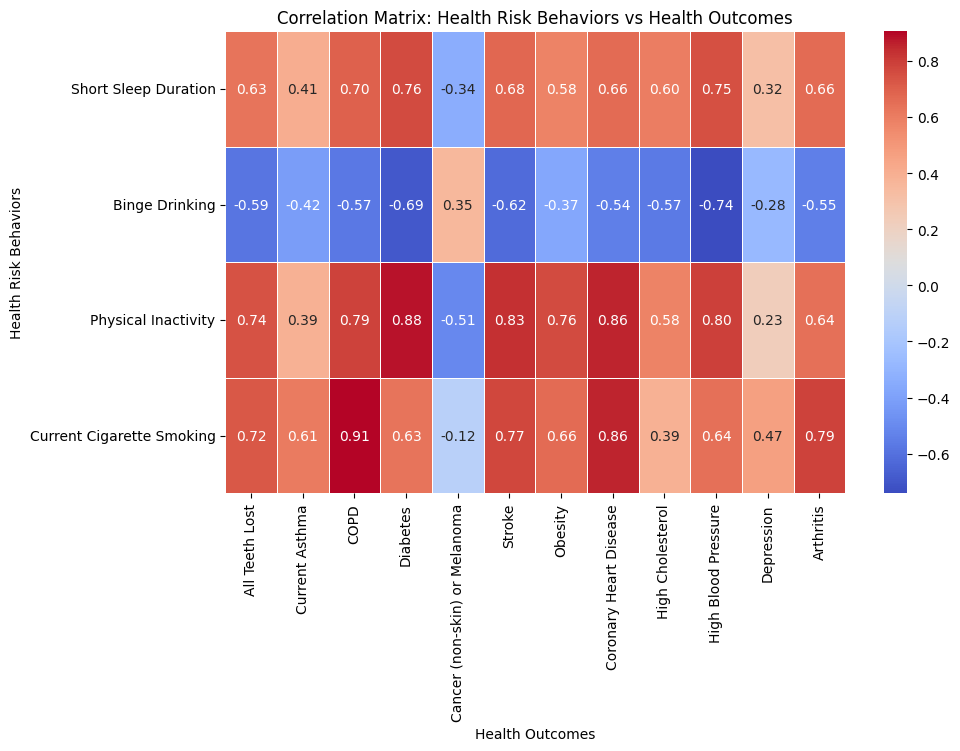

In [32]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Set labels
plt.title("Correlation Matrix: Health Risk Behaviors vs Health Outcomes")
plt.xlabel("Health Outcomes")
plt.ylabel("Health Risk Behaviors")

# Show plot
plt.show()


#### Each cell represents the **linear correlation coefficient** between a **health risk behavior** (rows) and a **health outcome** (columns). The **color intensity** reflects the strength and direction of the correlation.

### **Positive vs. Negative Correlations**
- **Warm colors** (reds) indicate **strong positive correlations**, meaning that as the health risk behavior increases, the corresponding health outcome also tends to increase.
- **Cool colors** (blues) represent **negative or weaker correlations**, suggesting an inverse or negligible relationship.

1. **Strong Positive Correlations**
- Current cigarette smoking is strongly correlated with COPD and other respiratory diseases, reinforcing well-established links between smoking and lung damage.
- Physical inactivity and short sleep duration exhibit consistent positive correlations with several chronic conditions, suggesting that sedentary lifestyles and poor sleep patterns may contribute to overall health decline.

2. **Weaker or Negative Correlations**
- Binge drinking appears to have weak or negative correlations with many health outcomes.
- One possible explanation is that binge drinking is more prevalent in relatively wealthier populations, where better access to healthcare and other lifestyle factors may mitigate some of its negative effects.
- However, this claim requires further research to account for confounding factors such as alcohol-related diseases (e.g., liver disease) that might not be captured in this dataset.

**Hispanic or Latino:**

1. **Worse Health Outcomes in Mississippi**

- Mississippi has higher rates of arthritis, COPD, obesity, and high blood pressure compared to Alaska, suggesting poorer **health overall.

2. **Mental Health and Chronic Illnesses Worse in Mississippi**

- Depression and cardiovascular risks are higher in Mississippi.

3. **Greater Health Inequality in Mississippi**

- Mississippi shows more health variability, especially in obesity and high cholesterol, pointing to wider disparities.

4. **Oral Health Worse in Mississippi**

- Higher rates of tooth loss in Mississippi suggest economic barriers to dental care.

5. **Similar Cancer and Stroke Rates**

- Cancer and stroke rates are similar between states, implying factors beyond poverty influence these conditions.

## Clustering Counties and States

Finally, we used K-Means and hierarchical clustering to see whether counties, and states, naturally group into distinct poverty/health profiles without giving the model any labels.

Visualization PCA Explained Variance Ratio (Health Outcomes): [0.66427219 0.17803825]


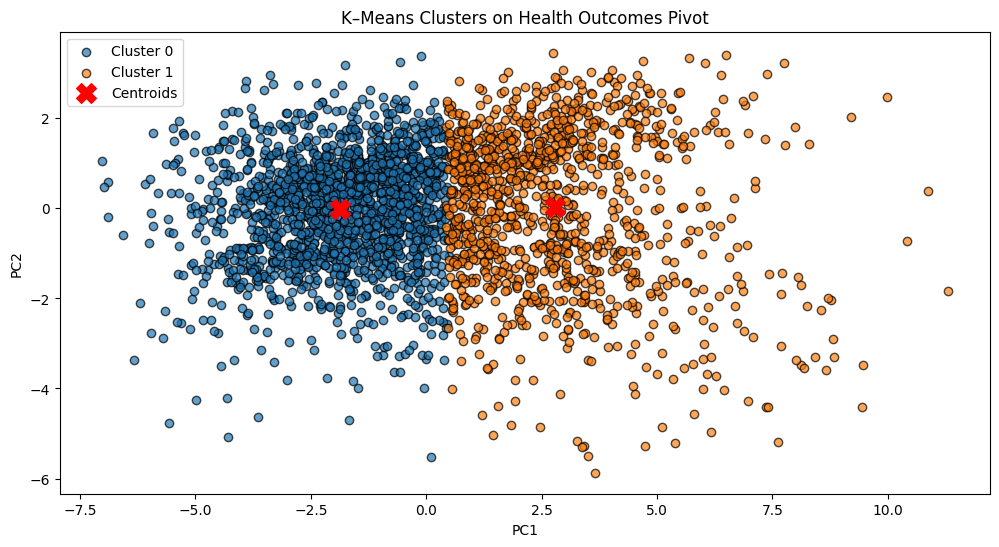

In [15]:
visualize_clusters_PCA(pipe_disease, X_transformed_disease, centroids_disease, clusters_disease, optimal_k_disease, "Health Outcomes")

We can gather the following insights from our **two** clusters on health outcomes and poverty levels:

####  **Cluster 0: Lower-Poverty, Better Health Outcomes**
- **BP_ Total% is 11.15**, which is **3.23 percentage points below the national average** — indicating this cluster contains **counties with relatively low poverty rates**.
- Health outcomes are generally better than average:
  - **Obesity (35.89%)**, **diabetes (9.79%)**, **high blood pressure (29.83%)**, and **all teeth lost (12.88%)** are all **lower than the national averages**.
  - This cluster is **below the mean** in nearly every major health condition, suggesting healthier populations and potentially better healthcare access.
  - **Cancer** doesn't follow this trend, as evidenced by our **Project Part 2** analysis that it doesn't have a positive correlation with increasing poverty levels.

---

####  **Cluster 1: Higher-Poverty, Poorer Health Outcomes**
- **BP_ Total% is 19.20**, which is **4.81 percentage points above the national average** — showing this cluster includes **counties with significantly higher poverty levels**.
- Health outcomes are worse across the board:
  - Higher rates of **obesity (41.26%)**, **diabetes (13.18%)**, **tooth loss (21.22%)**, and **stroke (4.05%)**.
  - This cluster is **consistently above the overall mean** in almost all categories, showing clear signs of health disparities.
  - **Cancer**, again, doesn't follow this trend.

---

####  **Key Takeaway**
- These results clearly separate counties into two groups that reflect **socioeconomic and health divides**.
- **Cluster 0** includes healthier, wealthier counties, while **Cluster 1** includes more disadvantaged areas with worse health outcomes.
- This supports previous findings from **Project Part 2** that poverty is deeply tied to public health — and further validates the use of clustering to uncover structural patterns in population health data.

## The Clearest Pattern: State-Level Clusters

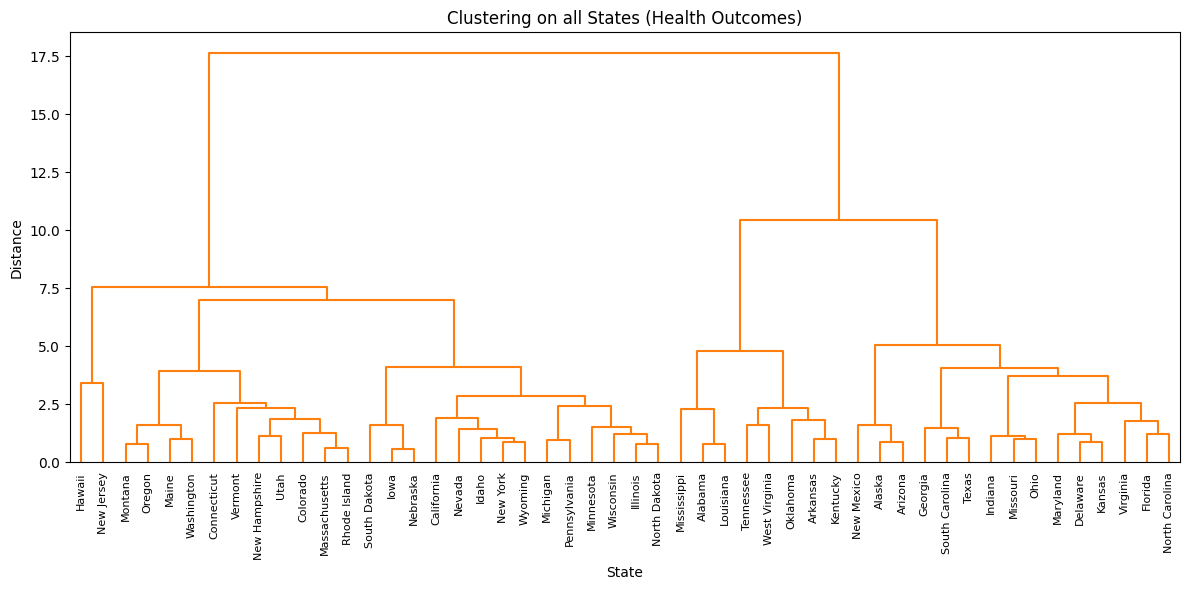

In [33]:
# Show the overall dendrogram for all states:
dendrogram_for_all_states(df_pivot_disease, pipe_disease, "Health Outcomes")

The dendrogram reveals that **Hawaii and New Jersey** form a unique cluster, standing apart from all other states — reflecting their **exceptionally low total poverty rates and strong health outcomes**. At the other end, states like **Mississippi, Louisiana, West Virginia, and Alabama** are tightly grouped, highlighting their **shared high total poverty and the worst health metrics**. A large middle group of states (e.g., **Wisconsin, Pennsylvania, Colorado, Iowa**) clusters closer together, suggesting **moderate poverty levels and relatively balanced health profiles**.

## Takeaway

Across every level of analysis, poverty and health outcomes moved together, poorer counties and states showed consistently worse rates of chronic disease, and clustering confirmed it wasn't just a Michigan pattern. Hawaii and New Jersey stood out nationally as the healthiest, wealthiest cluster, while high-poverty Southern states clustered tightly together on nearly every health metric we tested.